# 02 — Implied Volatility Surface

Fit and visualise an implied volatility surface from the options chain in `data/sample_chain.csv`.


In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from pricer import implied_vol as iv


## 1. Load and inspect the chain

In [2]:
chain = pd.read_csv('../data/sample_chain.csv')
print(f"Contracts: {len(chain):,}")
print(f"Expiries:  {sorted(chain['expiry_date'].unique())}")
print(f"Strike range: {chain['strike'].min()} – {chain['strike'].max()}")
print()
print(chain.head(8).to_string(index=False))


Contracts: 266
Expiries:  ['2025-02-21', '2025-03-21', '2025-06-20', '2025-09-19', '2025-12-19']
Strike range: 390 – 520

ticker kind  strike  expiry expiry_date   mid   bid   ask  last_price  volume  open_interest  implied_volatility_yf     S     r     q
   SPY call     390 0.10137  2025-02-21 61.51 61.05 61.97       61.05      27           1769                 0.1637 450.0 0.053 0.013
   SPY call     395 0.10137  2025-02-21 56.56 56.13 56.98       55.39    1585           3467                 0.1633 450.0 0.053 0.013
   SPY call     400 0.10137  2025-02-21 51.62 51.23 52.01       50.14      62            498                 0.1629 450.0 0.053 0.013
   SPY  put     400 0.10137  2025-02-21  0.07  0.06  0.08        0.07     213             62                 0.1629 450.0 0.053 0.013
   SPY call     405 0.10137  2025-02-21 46.71 46.36 47.06       46.52     505            111                 0.1626 450.0 0.053 0.013
   SPY  put     405 0.10137  2025-02-21  0.14  0.13  0.15        0.14     

## 2. Solve implied vols

In [3]:
df, interp = iv.fit_surface(chain)
print(f"Valid IVs: {len(df):,} / {len(chain):,}")
print(f"IV range:  {df['iv'].min():.1%} – {df['iv'].max():.1%}")
df[['kind','strike','expiry_date','mid','iv']].head(10)


Valid IVs: 266 / 266
IV range:  15.3% – 16.5%


,kind,strike,expiry_date,mid,iv
0,call,390,2025-02-21,61.51,0.161129
1,call,395,2025-02-21,56.56,0.164657
2,call,400,2025-02-21,51.62,0.162868
3,put,400,2025-02-21,0.07,0.163061
4,call,405,2025-02-21,46.71,0.161785
5,put,405,2025-02-21,0.14,0.163078
6,call,410,2025-02-21,41.86,0.162112
7,put,410,2025-02-21,0.26,0.162568
8,call,415,2025-02-21,37.09,0.161922
9,put,415,2025-02-21,0.46,0.161995


## 3. IV smile per expiry

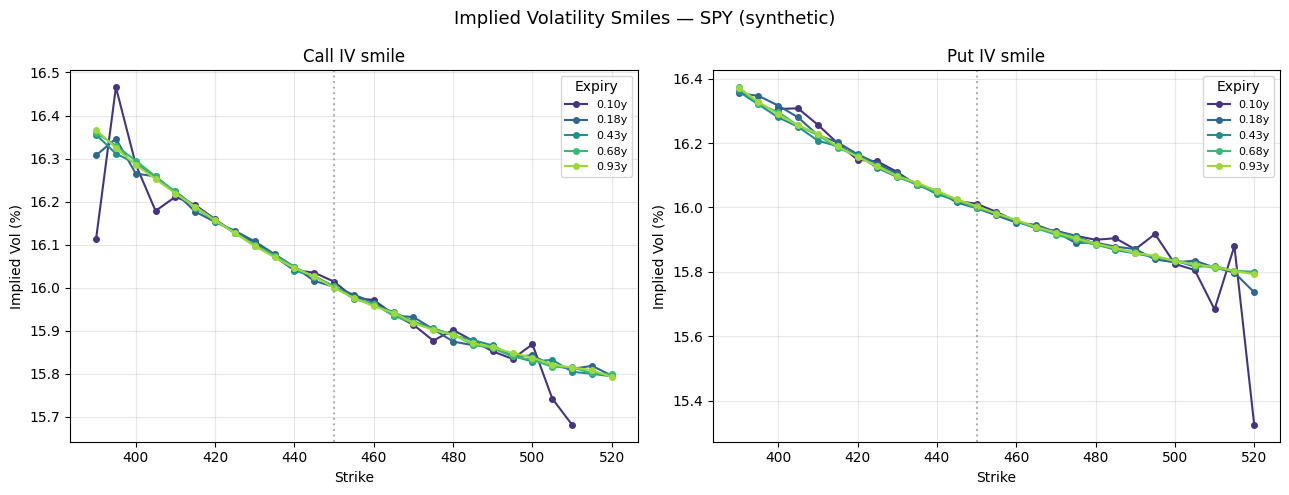

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = plt.cm.viridis(np.linspace(0.15, 0.85, df['expiry_date'].nunique()))

for ax, kind in zip(axes, ('call', 'put')):
    sub = df[df['kind'] == kind]
    for color, (exp, grp) in zip(colors, sub.groupby('expiry_date')):
        grp = grp.sort_values('strike')
        T_label = f"{grp['expiry'].iloc[0]:.2f}y"
        ax.plot(grp['strike'], grp['iv'] * 100, 'o-',
                ms=4, lw=1.5, color=color, label=T_label)
    ax.set_xlabel('Strike')
    ax.set_ylabel('Implied Vol (%)')
    ax.set_title(f'{kind.capitalize()} IV smile')
    ax.legend(title='Expiry', fontsize=8)
    ax.grid(alpha=0.3)
    S = df['S'].iloc[0]
    ax.axvline(S, color='grey', ls=':', alpha=0.6, label='Spot')

plt.suptitle('Implied Volatility Smiles — SPY (synthetic)', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/iv_smiles.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. 3-D volatility surface

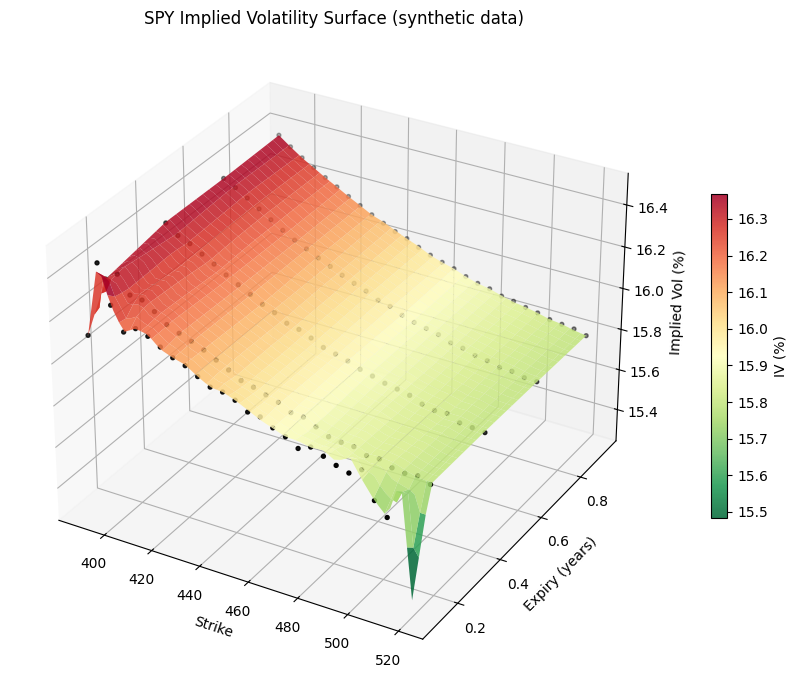

In [5]:
calls = df[df['kind'] == 'call'].copy()
calls = calls.sort_values(['expiry', 'strike'])

K_vals = np.linspace(calls['strike'].min(), calls['strike'].max(), 60)
T_vals = np.linspace(calls['expiry'].min(),  calls['expiry'].max(),  30)
KK, TT = np.meshgrid(K_vals, T_vals)

ZZ = interp(KK.ravel(), TT.ravel()).reshape(KK.shape)

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(KK, TT, ZZ * 100,
                       cmap='RdYlGn_r', alpha=0.85, linewidth=0, antialiased=True)
ax.scatter(calls['strike'], calls['expiry'], calls['iv'] * 100,
           color='k', s=8, zorder=5, label='Market IVs')
fig.colorbar(surf, ax=ax, shrink=0.5, label='IV (%)')
ax.set_xlabel('Strike')
ax.set_ylabel('Expiry (years)')
ax.set_zlabel('Implied Vol (%)')
ax.set_title('SPY Implied Volatility Surface (synthetic data)')
plt.tight_layout()
plt.savefig('../notebooks/iv_surface_3d.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Term structure at ATM

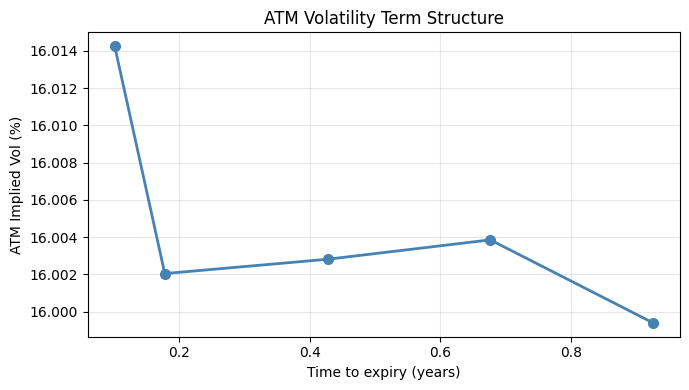

In [6]:
S = df['S'].iloc[0]
# Nearest strike to spot for each expiry
atm = (
    df[df['kind'] == 'call']
    .assign(dist=lambda x: (x['strike'] - S).abs())
    .sort_values(['expiry_date', 'dist'])
    .groupby('expiry_date')
    .first()
    .reset_index()
    .sort_values('expiry')
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(atm['expiry'], atm['iv'] * 100, 'o-', color='steelblue', ms=7, lw=2)
ax.set_xlabel('Time to expiry (years)')
ax.set_ylabel('ATM Implied Vol (%)')
ax.set_title('ATM Volatility Term Structure')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/iv_term_structure.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. IV vs YF implied vol

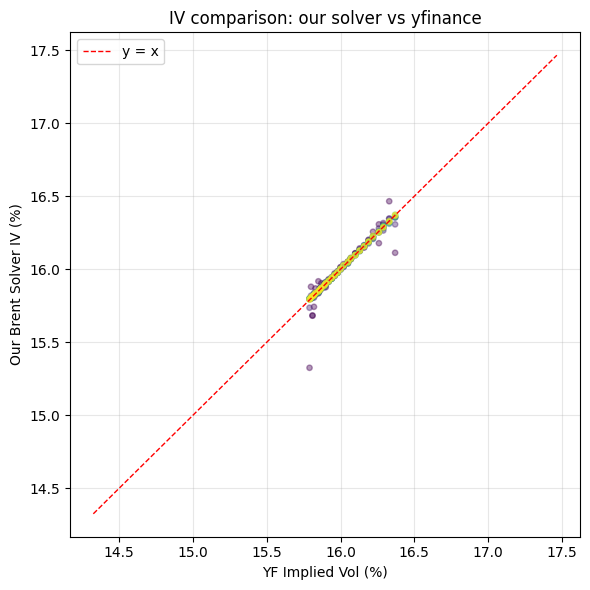

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['implied_volatility_yf'] * 100, df['iv'] * 100,
           alpha=0.4, s=15, c=df['expiry'], cmap='viridis')
lo = df[['implied_volatility_yf', 'iv']].min().min() * 100 - 1
hi = df[['implied_volatility_yf', 'iv']].max().max() * 100 + 1
ax.plot([lo, hi], [lo, hi], 'r--', lw=1, label='y = x')
ax.set_xlabel('YF Implied Vol (%)')
ax.set_ylabel('Our Brent Solver IV (%)')
ax.set_title('IV comparison: our solver vs yfinance')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/iv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
